# Bias and disparity analysis (regression)

This notebook checks whether **prediction error** differs across **groups** (e.g. city, traffic, weather). For regression, a common notion of *disparate impact* is **disparate error**: some groups get systematically higher MAE or different signed bias than others.

**Important:** This dataset does not include legally protected attributes (e.g. race). We analyze **operational / proxy** slices that can still matter for fairness to customers or drivers (geography, conditions).

**Model:** `models/model_validation.pkl` (same holdout logic as `04_modeling.ipynb` — trained on 80% train split, evaluated on 20% validation).

**Environment:** Run this notebook in the **same venv** (and ideally the same **scikit-learn** version) as `04_modeling.ipynb`. A different sklearn version can make `joblib.load` fail on the saved pipeline.


In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import train_test_split

# Project root (notebook lives in bias_analysis/)
ROOT = Path.cwd().resolve()
if ROOT.name == "bias_analysis":
    ROOT = ROOT.parent
if not (ROOT / "src").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

from src.data_preprocessing import load_clean_data
from src.model_config import DROP_COLS, TARGET
from src.scoring import load_model

RANDOM_STATE = 42
TEST_SIZE = 0.2
MIN_GROUP_N = 30  # skip tiny groups for disparity ratios

MODEL_PATH = ROOT / "models" / "model_validation.pkl"
DATA_PATH = ROOT / "data" / "processed" / "cleaned_delivery_data.csv"
VAL_PRED_CSV = ROOT / "reports" / "validation_predictions.csv"

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
print("ROOT:", ROOT)


ROOT: C:\Users\lynny\OneDrive\Desktop\uni\year 4\winter2026\aba DSAI4103 Business Analytics\project\food-delivery-time-prediction


In [2]:
# Load model (fallback to full-data model if validation artifact missing)
if MODEL_PATH.is_file():
    model = load_model(MODEL_PATH)
    print("Loaded:", MODEL_PATH)
else:
    alt = ROOT / "models" / "model_full.pkl"
    if alt.is_file():
        model = load_model(alt)
        print("WARNING: using full-data model; split is still 20% holdout for error analysis.")
        print("Loaded:", alt)
    else:
        raise FileNotFoundError(f"No model at {MODEL_PATH} or {alt}")


Loaded: C:\Users\lynny\OneDrive\Desktop\uni\year 4\winter2026\aba DSAI4103 Business Analytics\project\food-delivery-time-prediction\models\model_validation.pkl


In [3]:
# Reproduce validation split from 04_modeling.ipynb
train_df = load_clean_data(DATA_PATH)
X = train_df.drop(columns=[TARGET])
y = train_df[TARGET]
X = X.drop(columns=[c for c in DROP_COLS if c in X.columns])

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE
)

pred_val = model.predict(X_val)

mae = mean_absolute_error(y_val, pred_val)
rmse = mean_squared_error(y_val, pred_val) ** 0.5
print(f"Validation MAE:  {mae:.4f}")
print(f"Validation RMSE: {rmse:.4f}")
print(f"Validation rows: {len(y_val)}")


Validation MAE:  3.0497
Validation RMSE: 3.7993
Validation rows: 9017


In [4]:
# Optional: sanity check against reports/validation_predictions.csv
if VAL_PRED_CSV.is_file():
    csv_df = pd.read_csv(VAL_PRED_CSV)
    csv_df["order_id"] = csv_df["order_id"].astype(str)
    ids = train_df.loc[X_val.index, "order_id"].astype(str).values
    chk = pd.DataFrame({"order_id": ids, "pred_notebook": pred_val})
    merged = chk.merge(
        csv_df[["order_id", "predicted_delivery_time_min"]], on="order_id", how="left"
    )
    if merged["predicted_delivery_time_min"].notna().all() and len(merged) == len(pred_val):
        diff = (
            merged["pred_notebook"] - merged["predicted_delivery_time_min"]
        ).abs().max()
        print(f"Max |pred - validation_predictions.csv|: {diff:.6f}")
    else:
        print("Could not align all rows to validation_predictions.csv; skip check.")
else:
    print("No validation_predictions.csv; skip CSV check.")


Max |pred - validation_predictions.csv|: 0.000000


In [5]:
# Frame for group-wise analysis (features + errors)
analysis = X_val.copy()
analysis["actual"] = y_val.values
analysis["predicted"] = pred_val
analysis["signed_error"] = analysis["predicted"] - analysis["actual"]
analysis["abs_error"] = analysis["signed_error"].abs()

if "distance_km" in analysis.columns:
    analysis["distance_bin"] = pd.qcut(
        analysis["distance_km"], q=4, duplicates="drop"
    ).astype(str)

GROUP_COLS = [
    c
    for c in [
        "city",
        "traffic_density",
        "weather",
        "order_type",
        "vehicle_type",
        "is_festival",
        "order_day",
        "is_peak_hour",
        "is_weekend",
        "distance_bin",
    ]
    if c in analysis.columns
]
print("Grouping columns:", GROUP_COLS)


Grouping columns: ['city', 'traffic_density', 'weather', 'order_type', 'vehicle_type', 'is_festival', 'order_day', 'is_peak_hour', 'is_weekend', 'distance_bin']


In [6]:
def group_metrics(df: pd.DataFrame, col: str) -> pd.DataFrame:
    # Per-group error stats

    def _agg(sub: pd.DataFrame) -> pd.Series:
        return pd.Series(
            {
                "n": len(sub),
                "mae": sub["abs_error"].mean(),
                "rmse": mean_squared_error(sub["actual"], sub["predicted"]) ** 0.5,
                "mean_signed_error": sub["signed_error"].mean(),
                "median_abs_error": sub["abs_error"].median(),
            }
        )

    out = df.groupby(col, observed=True).apply(_agg, include_groups=False)
    return out.sort_values("mae", ascending=False)


def disparity_ratio(mae_by_group: pd.Series, counts: pd.Series, min_n: int) -> float:
    # max MAE / min MAE among groups with n >= min_n
    ok = counts >= min_n
    mae = mae_by_group[ok]
    if len(mae) < 2:
        return float("nan")
    return float(mae.max() / mae.min())


def mae_spread(mae_by_group: pd.Series, counts: pd.Series, min_n: int) -> float:
    ok = counts >= min_n
    mae = mae_by_group[ok]
    if len(mae) < 2:
        return float("nan")
    return float(mae.max() - mae.min())


In [7]:
# Per-attribute tables + disparity summaries
summary_rows = []
all_tables = {}

for col in GROUP_COLS:
    gm = group_metrics(analysis, col)
    all_tables[col] = gm
    dr = disparity_ratio(gm["mae"], gm["n"], MIN_GROUP_N)
    sp = mae_spread(gm["mae"], gm["n"], MIN_GROUP_N)
    summary_rows.append(
        {
            "attribute": col,
            "n_groups": len(gm),
            "groups_ge_min_n": int((gm["n"] >= MIN_GROUP_N).sum()),
            "overall_mae_weighted": float((gm["mae"] * gm["n"]).sum() / gm["n"].sum()),
            "disparity_ratio_mae": dr,
            "mae_spread_max_minus_min": sp,
            "worst_group": gm["mae"].idxmax(),
            "best_group": gm["mae"].idxmin(),
        }
    )

disparity_summary = pd.DataFrame(summary_rows).sort_values(
    "disparity_ratio_mae", ascending=False
)
display(disparity_summary)


,attribute,n_groups,groups_ge_min_n,overall_mae_weighted,disparity_ratio_mae,mae_spread_max_minus_min,worst_group,best_group
1,traffic_density,4,4,3.049699,1.284569,0.767416,Jam,Low
2,weather,6,6,3.049699,1.208325,0.569369,Windy,Cloudy
9,distance_bin,4,4,3.049699,1.199519,0.558316,"(13.681, 20.969]","(1.4640000000000002, 4.658]"
5,is_festival,2,2,3.049699,1.124247,0.337697,No,Yes
6,order_day,7,7,3.049699,1.102170,0.301946,Wednesday,Thursday
7,is_peak_hour,2,2,3.049699,1.088689,0.257356,1,0
4,vehicle_type,4,3,3.049699,1.061211,0.180085,bicycle,scooter
3,order_type,4,4,3.049699,1.031060,0.092825,Buffet,Snack
0,city,3,2,3.049699,1.021840,0.066239,Semi-Urban,Metropolitian
8,is_weekend,2,2,3.049699,1.005000,0.015229,1,0


In [8]:
# Detail for highest-disparity attributes
for col in disparity_summary.head(3)["attribute"]:
    print("\n" + "=" * 60)
    print(col)
    print("=" * 60)
    display(all_tables[col])



traffic_density


,n,mae,rmse,mean_signed_error,median_abs_error
traffic_density,,,,,
Jam,2737.0,3.464185,4.249223,0.055807,3.091433
High,919.0,3.122654,4.029941,-0.058686,2.645243
Medium,2190.0,3.012093,3.738957,0.015573,2.606951
Low,3171.0,2.696769,3.331681,0.144754,2.383623



weather


,n,mae,rmse,mean_signed_error,median_abs_error
weather,,,,,
Windy,1457.0,3.302451,4.103283,0.218435,2.945239
Stormy,1480.0,3.259302,4.060672,0.031352,2.785745
Sandstorms,1455.0,3.207196,4.012274,0.024364,2.757185
Sunny,1475.0,2.942458,3.576308,0.187020,2.734091
Fog,1603.0,2.887725,3.682468,0.023227,2.466671
Cloudy,1547.0,2.733082,3.334119,-0.078388,2.302772



distance_bin


,n,mae,rmse,mean_signed_error,median_abs_error
distance_bin,,,,,
"(13.681, 20.969]",2250.0,3.356623,4.093937,0.079715,3.038226
"(9.192, 13.681]",2256.0,3.204071,3.928280,0.052764,2.896713
"(4.658, 9.192]",2255.0,2.840518,3.657057,0.061788,2.335976
"(1.4640000000000002, 4.658]",2256.0,2.798307,3.489831,0.068353,2.474508


In [9]:
# Kruskal–Wallis: do abs_error distributions differ across groups?
kw_rows = []
for col in GROUP_COLS:
    groups = [g["abs_error"].values for _, g in analysis.groupby(col, observed=True)]
    groups = [x for x in groups if len(x) >= MIN_GROUP_N]
    if len(groups) < 2:
        continue
    stat, p = stats.kruskal(*groups)
    kw_rows.append({"attribute": col, "H_stat": stat, "p_value": p})

kw_df = pd.DataFrame(kw_rows).sort_values("p_value")
kw_df["significant_0.05"] = kw_df["p_value"] < 0.05
display(kw_df)


,attribute,H_stat,p_value,significant_0.05
1,traffic_density,137.422336,1.358983e-29,True
9,distance_bin,115.685159,6.554996e-25,True
2,weather,56.683364,5.876820e-11,True
7,is_peak_hour,33.534695,7.000406e-09,True
6,order_day,23.691036,5.951880e-04,True
4,vehicle_type,12.243805,2.194278e-03,True
5,is_festival,2.596759,1.070825e-01,False
0,city,2.248403,1.337524e-01,False
3,order_type,3.978828,2.637594e-01,False
8,is_weekend,0.126029,7.225856e-01,False


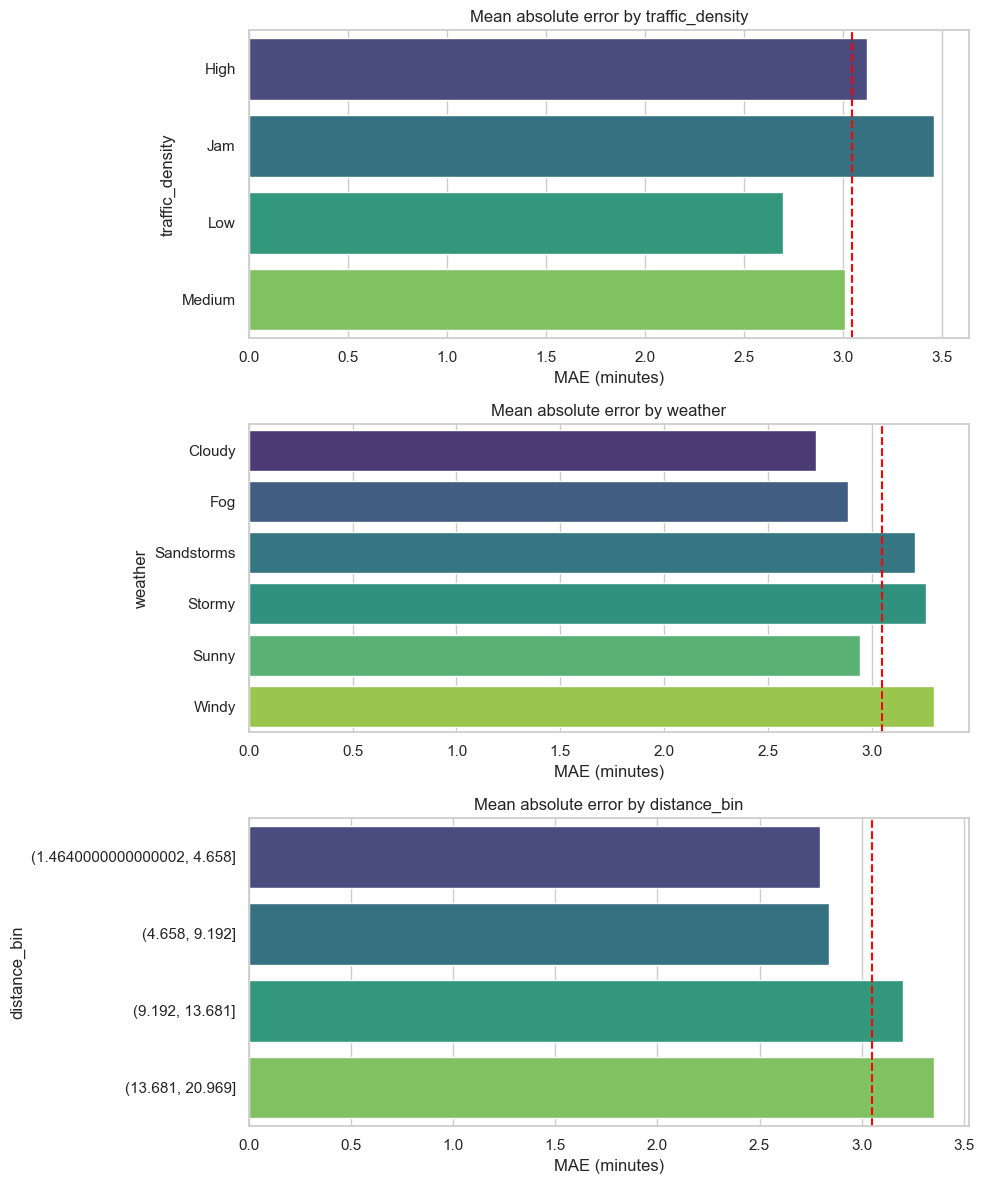

In [10]:
# Plots: MAE by group (top attributes by disparity ratio)
n_plot = min(3, len(disparity_summary))
fig, axes = plt.subplots(n_plot, 1, figsize=(10, 4 * n_plot))
if n_plot == 1:
    axes = [axes]

for ax, col in zip(axes, disparity_summary.head(n_plot)["attribute"]):
    gm = all_tables[col].reset_index()
    gm = gm[gm["n"] >= MIN_GROUP_N].sort_values("mae")
    sns.barplot(data=gm, x="mae", y=col, ax=ax, hue=col, legend=False, palette="viridis")
    ax.axvline(
        analysis["abs_error"].mean(), color="red", linestyle="--", label="Overall MAE"
    )
    ax.set_title(f"Mean absolute error by {col}")
    ax.set_xlabel("MAE (minutes)")
plt.tight_layout()
plt.show()


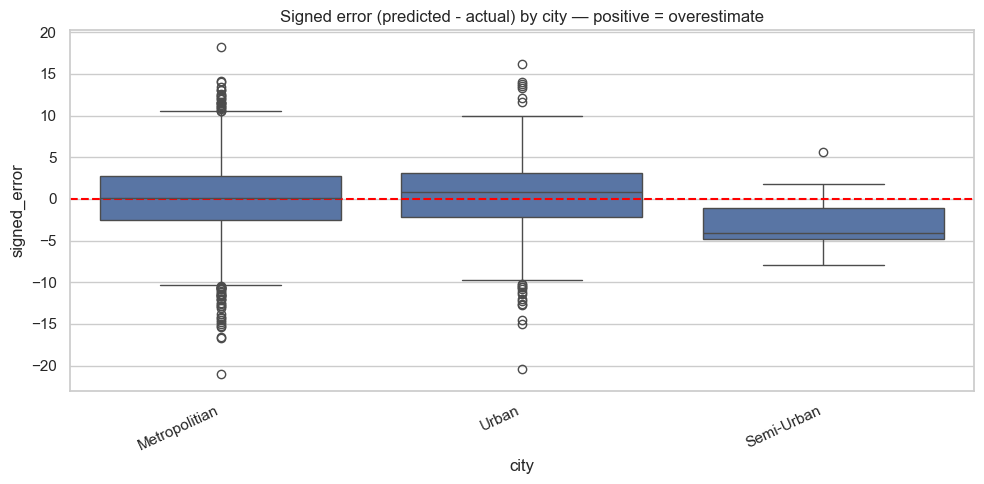

In [11]:
# Signed error: systematic over/under prediction (city)
if "city" in analysis.columns:
    plt.figure(figsize=(10, 5))
    order = analysis.groupby("city", observed=True)["abs_error"].mean().sort_values().index
    sns.boxplot(data=analysis, x="city", y="signed_error", order=order)
    plt.axhline(0, color="red", linestyle="--")
    plt.title("Signed error (predicted - actual) by city — positive = overestimate")
    plt.xticks(rotation=25, ha="right")
    plt.tight_layout()
    plt.show()


## All model input features (extended)

Below we slice **every column in `X_val`**:

- **Categorical / string** columns with at most `MAX_CAT_LEVELS` distinct values are used as-is.
- **Numeric** columns with few unique values (≤12) are grouped by level (`__lvl`).
- **Numeric** columns with many unique values are binned into **quartiles** (`__q4`).

This complements the hand-picked `GROUP_COLS` section above and feeds the disparity table, Kruskal tests, plots, and the closing summary.


In [12]:
# Build extended frame: one grouping dimension per input feature
analysis_full = X_val.copy()
analysis_full["actual"] = y_val.values
analysis_full["predicted"] = pred_val
analysis_full["signed_error"] = analysis_full["predicted"] - analysis_full["actual"]
analysis_full["abs_error"] = analysis_full["signed_error"].abs()

ALL_FEATURE_GROUP_COLS = []
MAX_CAT_LEVELS = 25

for col in X_val.columns:
    s = analysis_full[col]
    if pd.api.types.is_numeric_dtype(s):
        nuniq = int(s.nunique(dropna=False))
        if nuniq <= 12:
            gcol = f"{col}__lvl"
            analysis_full[gcol] = s.astype(str)
            ALL_FEATURE_GROUP_COLS.append(gcol)
        else:
            gcol = f"{col}__q4"
            try:
                analysis_full[gcol] = pd.qcut(s, q=4, duplicates="drop").astype(str)
                ALL_FEATURE_GROUP_COLS.append(gcol)
            except Exception as ex:
                print(f"Skipped quartiles for {col}: {ex}")
    else:
        nuniq = s.astype(str).nunique(dropna=False)
        if nuniq <= MAX_CAT_LEVELS:
            ALL_FEATURE_GROUP_COLS.append(col)
        else:
            print(f"Skipped (>{MAX_CAT_LEVELS} levels): {col}")

print(f"Extended grouping columns ({len(ALL_FEATURE_GROUP_COLS)}):", ALL_FEATURE_GROUP_COLS)


Extended grouping columns (15): ['driver_age__q4', 'driver_rating__q4', 'weather', 'traffic_density', 'vehicle_condition__lvl', 'order_type', 'vehicle_type', 'num_deliveries__lvl', 'is_festival', 'city', 'distance_km__q4', 'order_hour__q4', 'order_day', 'is_weekend__lvl', 'is_peak_hour__lvl']


In [13]:
# Disparity metrics for every grouping column
summary_all_rows = []
all_tables_full = {}

for col in ALL_FEATURE_GROUP_COLS:
    try:
        gm = group_metrics(analysis_full, col)
    except Exception as ex:
        print(f"group_metrics failed {col}: {ex}")
        continue
    all_tables_full[col] = gm
    dr = disparity_ratio(gm["mae"], gm["n"], MIN_GROUP_N)
    sp = mae_spread(gm["mae"], gm["n"], MIN_GROUP_N)
    summary_all_rows.append(
        {
            "attribute": col,
            "n_groups": len(gm),
            "groups_ge_min_n": int((gm["n"] >= MIN_GROUP_N).sum()),
            "overall_mae_weighted": float((gm["mae"] * gm["n"]).sum() / gm["n"].sum()),
            "disparity_ratio_mae": dr,
            "mae_spread_max_minus_min": sp,
            "worst_group": gm["mae"].idxmax(),
            "best_group": gm["mae"].idxmin(),
        }
    )

disparity_summary_all = pd.DataFrame(summary_all_rows).sort_values(
    "disparity_ratio_mae", ascending=False, na_position="last"
)


In [14]:
display(disparity_summary_all)


,attribute,n_groups,groups_ge_min_n,overall_mae_weighted,disparity_ratio_mae,mae_spread_max_minus_min,worst_group,best_group
4,vehicle_condition__lvl,4,4,3.049699,2.000748,2.889596,3,2
11,order_hour__q4,5,5,3.049699,1.872241,2.288595,nan,"(21.0, 23.0]"
3,traffic_density,4,4,3.049699,1.284569,0.767416,Jam,Low
2,weather,6,6,3.049699,1.208325,0.569369,Windy,Cloudy
10,distance_km__q4,4,4,3.049699,1.199519,0.558316,"(13.681, 20.969]","(1.4640000000000002, 4.658]"
7,num_deliveries__lvl,4,4,3.049699,1.179044,0.469071,1,3
0,driver_age__q4,4,4,3.049699,1.167310,0.473027,"(25.0, 30.0]","(34.0, 39.0]"
1,driver_rating__q4,4,4,3.049699,1.166276,0.483593,"(4.6, 4.7]","(4.7, 4.8]"
8,is_festival,2,2,3.049699,1.124247,0.337697,No,Yes
12,order_day,7,7,3.049699,1.102170,0.301946,Wednesday,Thursday


In [15]:
# Detailed tables for top attributes by disparity ratio
for col in disparity_summary_all.head(8)["attribute"]:
    print("\n" + "=" * 72)
    print(col)
    print("=" * 72)
    display(all_tables_full[col])



vehicle_condition__lvl


,n,mae,rmse,mean_signed_error,median_abs_error
vehicle_condition__lvl,,,,,
3,64.0,5.777030,7.042788,0.667874,5.211838
0,3007.0,3.276850,4.127173,0.124999,2.838255
1,3027.0,2.922859,3.586088,0.071554,2.554277
2,2919.0,2.887434,3.552399,-0.014826,2.548389



order_hour__q4


,n,mae,rmse,mean_signed_error,median_abs_error
order_hour__q4,,,,,
nan,269.0,4.912404,6.501312,0.463031,3.693479
"(19.0, 21.0]",1752.0,3.450993,4.173112,0.185259,3.112648
"(15.0, 19.0]",2826.0,3.145823,3.869447,-0.035444,2.820006
"(-0.001, 15.0]",2341.0,2.752036,3.445168,0.013904,2.391954
"(21.0, 23.0]",1829.0,2.623809,3.152671,0.115045,2.364163



traffic_density


...

,n,mae,rmse,mean_signed_error,median_abs_error
num_deliveries__lvl,,,,,
1,5770.0,3.088933,3.859861,-0.009042,2.681149
0,2802.0,2.989594,3.710724,0.302680,2.601074
2,375.0,2.975352,3.614727,-0.414711,2.646925
3,70.0,2.619862,3.188547,-0.692695,2.334477



driver_age__q4


,n,mae,rmse,mean_signed_error,median_abs_error
driver_age__q4,,,,,
"(25.0, 30.0]",2529.0,3.300273,4.215484,0.143974,2.758021
"(19.999, 25.0]",2572.0,3.112128,3.791005,0.140577,2.839122
"(30.0, 34.0]",1738.0,2.871465,3.535508,-0.058921,2.521549
"(34.0, 39.0]",2178.0,2.827246,3.489999,-0.014389,2.426695



driver_rating__q4


,n,mae,rmse,mean_signed_error,median_abs_error
driver_rating__q4,,,,,
"(4.6, 4.7]",1763.0,3.391963,4.336003,0.223074,2.853840
"(2.499, 4.6]",3626.0,3.014223,3.720459,0.042336,2.648411
"(4.8, 5.0]",2191.0,2.925697,3.612415,-0.083652,2.535573
"(4.7, 4.8]",1437.0,2.908370,3.561772,0.158959,2.615788


In [16]:
# Kruskal–Wallis on abs_error for every feature slice
kw_all_rows = []
for col in ALL_FEATURE_GROUP_COLS:
    try:
        groups = [
            g["abs_error"].values
            for _, g in analysis_full.groupby(col, observed=True)
        ]
        groups = [x for x in groups if len(x) >= MIN_GROUP_N]
        if len(groups) < 2:
            continue
        stat, p = stats.kruskal(*groups)
        kw_all_rows.append({"attribute": col, "H_stat": stat, "p_value": p})
    except Exception as ex:
        print(f"Kruskal skip {col}: {ex}")

kw_all = pd.DataFrame(kw_all_rows).sort_values("p_value")
kw_all["significant_0.05"] = kw_all["p_value"] < 0.05
display(kw_all)


,attribute,H_stat,p_value,significant_0.05
11,order_hour__q4,181.600950,3.378312e-38,True
3,traffic_density,137.422336,1.358983e-29,True
10,distance_km__q4,115.685159,6.554996e-25,True
4,vehicle_condition__lvl,58.912748,1.003452e-12,True
2,weather,56.683364,5.876820e-11,True
14,is_peak_hour__lvl,33.534695,7.000406e-09,True
0,driver_age__q4,38.023966,2.793645e-08,True
1,driver_rating__q4,23.144040,3.768530e-05,True
12,order_day,23.691036,5.951880e-04,True
6,vehicle_type,12.243805,2.194278e-03,True


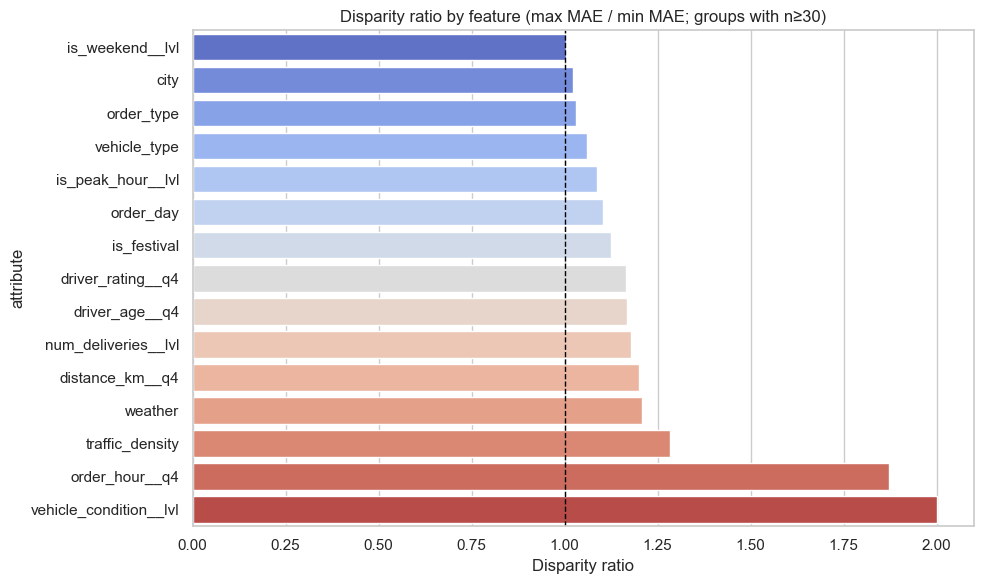

In [17]:
# Visual: disparity ratio for every feature (reference line = 1)
fig, ax = plt.subplots(figsize=(10, max(6, 0.38 * len(disparity_summary_all))))
plot_df = disparity_summary_all.dropna(subset=["disparity_ratio_mae"]).sort_values(
    "disparity_ratio_mae", ascending=True
)
sns.barplot(
    data=plot_df,
    y="attribute",
    x="disparity_ratio_mae",
    ax=ax,
    hue="attribute",
    palette="coolwarm",
    legend=False,
)
ax.axvline(1.0, color="black", linestyle="--", linewidth=1)
ax.set_title(
    f"Disparity ratio by feature (max MAE / min MAE; groups with n≥{MIN_GROUP_N})"
)
ax.set_xlabel("Disparity ratio")
plt.tight_layout()
plt.show()


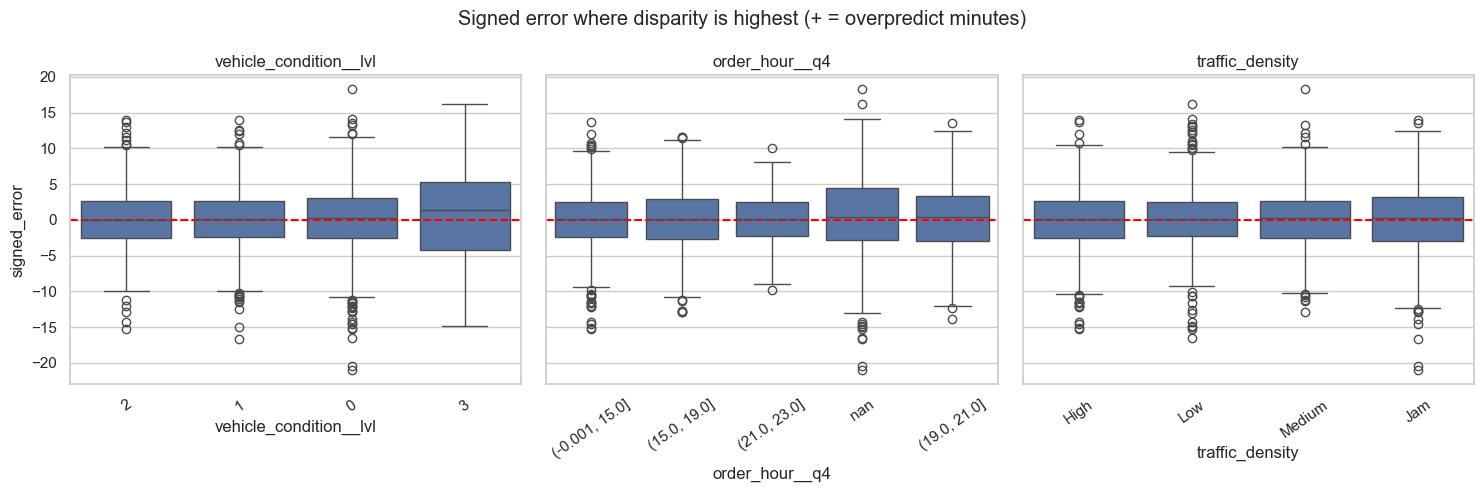

In [18]:
# Visual: signed error for the three highest-disparity dimensions
top3 = (
    disparity_summary_all.dropna(subset=["disparity_ratio_mae"])
    .head(3)["attribute"]
    .tolist()
)
if top3:
    fig, axes = plt.subplots(1, len(top3), figsize=(5 * len(top3), 5), sharey=True)
    if len(top3) == 1:
        axes = [axes]
    for ax, attr in zip(axes, top3):
        sub = analysis_full[[attr, "signed_error"]].copy()
        order = sub.groupby(attr, observed=True)["signed_error"].median().sort_values().index
        sns.boxplot(data=sub, x=attr, y="signed_error", order=order, ax=ax)
        ax.axhline(0, color="red", linestyle="--")
        ax.set_title(attr)
        ax.tick_params(axis="x", rotation=35)
    fig.suptitle("Signed error where disparity is highest (+ = overpredict minutes)")
    plt.tight_layout()
    plt.show()


In [19]:
# Auto-generated synthesis (statistics + visuals)
from IPython.display import Markdown, display as idisplay

overall_mae = float(analysis["abs_error"].mean())
lines = [
    "## Synthesis — what the bias analysis suggests",
    "",
    f"- **Overall validation MAE:** {overall_mae:.3f} minutes.",
    "",
    "### 1) Unequal absolute error (disparity ratio)",
    "- Ratios **above ~1.1–1.2** are often worth calling out; **>1.3** is a strong spread in typical coursework terms.",
    "",
]

top5 = disparity_summary_all.dropna(subset=["disparity_ratio_mae"]).head(5)
for _, r in top5.iterrows():
    wg, bg = r["worst_group"], r["best_group"]
    lines.append(
        f"- **{r['attribute']}**: disparity **{r['disparity_ratio_mae']:.2f}×** "
        f"(highest-MAE group `{wg!s}`, lowest `{bg!s}`; spread **{r['mae_spread_max_minus_min']:.2f}** min)."
    )

lines.extend(
    [
        "",
        "### 2) Kruskal–Wallis (do abs errors differ across groups?)",
    ]
)
sig = kw_all[kw_all["significant_0.05"]].sort_values("p_value")
if sig.empty:
    lines.append("- No attributes significant at α=0.05 (after the n≥30 group filter), or too few groups.")
else:
    for _, r in sig.head(10).iterrows():
        lines.append(f"- **{r['attribute']}**: p = {r['p_value']:.2e}.")

lines.extend(
    [
        "",
        "### 3) Direction of bias (signed error)",
        "- Compare boxplots above: **positive** median signed error ⇒ model **overpredicts** minutes for that slice.",
        "",
        "### 4) One-sentence takeaway to paste into your report (edit as needed)",
    ]
)
if len(top5):
    lines.append(
        f"- *The largest **MAE disparities** appear along **{top5.iloc[0]['attribute']}**; "
        f"statistical tests {'flag ' + str(len(sig)) + ' attribute(s)' if len(sig) else 'do not strongly flag'} "
        f"unequal absolute-error distributions at α=0.05.*"
    )
else:
    lines.append("- *No disparity ratios computed; check grouping columns / data.*")

lines.extend(
    [
        "",
        "_This describes **unequal predictive performance**, not legal discrimination._",
    ]
)

idisplay(Markdown("\n".join(lines)))


## Synthesis — what the bias analysis suggests

- **Overall validation MAE:** 3.050 minutes.

### 1) Unequal absolute error (disparity ratio)
- Ratios **above ~1.1–1.2** are often worth calling out; **>1.3** is a strong spread in typical coursework terms.

- **vehicle_condition__lvl**: disparity **2.00×** (highest-MAE group `3`, lowest `2`; spread **2.89** min).
- **order_hour__q4**: disparity **1.87×** (highest-MAE group `nan`, lowest `(21.0, 23.0]`; spread **2.29** min).
- **traffic_density**: disparity **1.28×** (highest-MAE group `Jam`, lowest `Low`; spread **0.77** min).
- **weather**: disparity **1.21×** (highest-MAE group `Windy`, lowest `Cloudy`; spread **0.57** min).
- **distance_km__q4**: disparity **1.20×** (highest-MAE group `(13.681, 20.969]`, lowest `(1.4640000000000002, 4.658]`; spread **0.56** min).

### 2) Kruskal–Wallis (do abs errors differ across groups?)
- **order_hour__q4**: p = 3.38e-38.
- **traffic_density**: p = 1.36e-29.
- **distance_km__q4**: p = 6.55e-25.
- **vehicle_condition__lvl**: p = 1.00e-12.
- **weather**: p = 5.88e-11.
- **is_peak_hour__lvl**: p = 7.00e-09.
- **driver_age__q4**: p = 2.79e-08.
- **driver_rating__q4**: p = 3.77e-05.
- **order_day**: p = 5.95e-04.
- **vehicle_type**: p = 2.19e-03.

### 3) Direction of bias (signed error)
- Compare boxplots above: **positive** median signed error ⇒ model **overpredicts** minutes for that slice.

### 4) One-sentence takeaway to paste into your report (edit as needed)
- *The largest **MAE disparities** appear along **vehicle_condition__lvl**; statistical tests flag 10 attribute(s) unequal absolute-error distributions at α=0.05.*

_This describes **unequal predictive performance**, not legal discrimination._

### Report checklist (manual polish)

- [ ] Name the **top 1–2 dimensions** with the highest disparity ratio and interpret in business language (traffic, weather, distance band, etc.).
- [ ] Connect **signed error**: who is systematically **over-** vs **under-** predicted?
- [ ] Mention **limitations**: proxy attributes, no causal claims, validation split is one sample of uncertainty.
- [ ] Optional: export `disparity_summary_all` / `kw_all` to CSV for Power BI.


## How to read the metrics

| Metric | Meaning |
|--------|--------|
| **MAE** | Average absolute error in minutes for that group. |
| **Mean signed error** | If positive, the model tends to **overpredict** time for that group; if negative, **underpredict**. |
| **Disparity ratio (MAE)** | `max MAE / min MAE` among groups with enough rows. Values **far above 1** mean error is much worse for some groups than others. |
| **MAE spread** | `max MAE − min MAE` in minutes. |
| **Kruskal–Wallis *p*** | Small *p* suggests **absolute errors are not drawn from the same distribution** across groups (heuristic; many groups and sample size affect *p*). |

**This does not prove illegal discrimination**; it flags **unequal model performance** across slices you care about.
